In [1]:
import matplotlib.pyplot as plt
import pymupdf4llm
import pymupdf
import glob
import sys
import os
import pandas as pd
import tqdm

sys.path.append("../src")
import text_extraction

In [2]:
path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/german_annual_reports/bayer-annual-report-2023-2.pdf"
path = '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/Deutsche Lufthansa AG1.pdf'

In [3]:
reports = glob.glob("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/*.pdf")
reports

['/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/Deutsche Lufthansa AG1.pdf',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/Hermes International SCA2.pdf',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/RWE AG1.pdf',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/Nordea Bank Abp1.pdf',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/Knorr-Bremse AG1.pdf',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/Rolls-Royce Holdings plc1.pdf',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/BAE Systems plc1.pdf',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/

In [4]:
text_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/german_annual_reports_no_tables"
text_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/german_annual_reports_text_one_font_size"

In [5]:
def is_block_within(block1, block2):
    """
    Returns True if block1 is fully inside block2's bounding box.
    Each block must have a 'bbox' key: [x0, y0, x1, y1]
    """
    x0_1, y0_1, x1_1, y1_1 = block1
    x0_2, y0_2, x1_2, y1_2 = block2
    
    return (
        x0_1 >= x0_2 and
        y0_1 >= y0_2 and
        x0_1 <= x1_2 and
        y0_1 <= y1_2
    )

In [6]:
def get_paragraphs(pdf_path: str):

    doc = pymupdf.open(pdf_path)
    uniform_blocks = []
    temp_text = ""
    temp_font_size = 0

    for page in doc:
        blocks = page.get_text("dict")["blocks"]
        for block in blocks:
            if "lines" in block.keys(): 
                for line in block["lines"]: 
                    for span in line["spans"]:
                        if span["text"].strip():
                            if span["size"] == temp_font_size:
                                temp_text += span["text"]
                            else:
                                if temp_text.strip() and any(char.isalpha() for char in temp_text):
                                    temp_dict = {"text": temp_text, "page": page.number, "font_size": temp_font_size}
                                    uniform_blocks.append(temp_dict)
                                temp_text = span["text"]
                                temp_font_size = span["size"]
    df = pd.DataFrame(uniform_blocks)

    return df


In [7]:
def get_paragraphs_max_font_size(pdf_path: str):

    doc = pymupdf.open(pdf_path)
    uniform_blocks = []
    temp_text = ""
    temp_font_size = 0

    for page in doc:
        blocks = page.get_text("dict")["blocks"]
        for block in blocks:
            if "lines" in block.keys(): 
                for line in block["lines"]: 
                    for span in line["spans"]:
                        if span["text"].strip():
                            if span["size"] == temp_font_size:
                                temp_text += span["text"]
                            else:
                                if temp_text.strip() and any(char.isalpha() for char in temp_text):
                                    temp_dict = {"text": temp_text, "page": page.number, "font_size": temp_font_size}
                                    uniform_blocks.append(temp_dict)
                                temp_text = span["text"]
                                temp_font_size = span["size"]
    df = pd.DataFrame(uniform_blocks)

    return df


In [ ]:
def get_paragraphs_without_table(pdf_path: str) -> pd.DataFrame:

    doc = pymupdf.open(pdf_path)
    uniform_blocks = []
    temp_text = ""
    temp_font_size = 0

    for i, page in tqdm.tqdm(enumerate(doc)): 
            
        tabs = page.find_tables()
        blocks = page.get_text("dict")["blocks"]
        
        if i == 50: 
            break

        for block in blocks:
            if block["type"] == 0:  # Nur Textblöcke (nicht Bilder)
                if not any([is_block_within(block["bbox"], tab.bbox) for tab in tabs]):             
                    if "lines" in block.keys(): 
                        for line in block["lines"]: 
                            for span in line["spans"]:
                                if span["text"].strip(): 
                                    if span["size"] == temp_font_size:
                                        temp_text += span["text"]
                                    else:
                                        if temp_text.strip() and any(char.isalpha() for char in temp_text):
                                            temp_dict = {"text": temp_text, "page": page.number, "font_size": temp_font_size}
                                            uniform_blocks.append(temp_dict)
                                        temp_text = span["text"]
                                        temp_font_size = span["size"]

    df = pd.DataFrame(uniform_blocks)

    df["len"] = df["text"].apply(len)
    df["share"] = df["len"] / df["len"].sum()    
    mode_font_size = df.groupby("font_size").sum().sort_values(by="share", ascending=False).iloc[0].name

    df = df[df["font_size"] == mode_font_size]

    return df

In [9]:
df = get_paragraphs_without_table(path)

0it [00:00, ?it/s]

37it [00:07,  3.70it/s]Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x107e66680>>
Traceback (most recent call last):
  File "/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
336it [01:29,  3.74it/s]
336it [01:30,  3.72it/s]
43it [00:09,  4.50it/s]

KeyboardInterrupt



In [10]:
def get_font_sizes(path): 
    df = get_paragraphs_without_table(path)
    df["len"] = df["text"].apply(len)
    df["share"] = df["len"] / df["len"].sum()    
    return df.groupby("font_size").sum().sort_values(by="share", ascending=False)

In [11]:
get_font_sizes(path)

46it [00:10,  4.18it/s]


KeyboardInterrupt: 

In [12]:
def extract_all_sizes(block):
    sizes = []
    for line in block.get("lines", []):
        for span in line.get("spans", []):
            if "size" in span:
                sizes.append(span["size"])
    return sizes

In [21]:
import fitz  # PyMuPDF
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import io

# --- Helper function ---
def is_block_within(block_bbox, table_bbox):
    bx0, by0, bx1, by1 = block_bbox
    tx0, ty0, tx1, ty1 = table_bbox
    return bx0 >= tx0 and by0 >= ty0 and bx1 <= tx1 and by1 <= ty1

# --- Load PDF ---

record_font_sizes = {}

for path in reports:

    doc = fitz.open(path)

    df = get_paragraphs_without_table(path)
    df["len"] = df["text"].apply(len)
    df["share"] = df["len"] / df["len"].sum()    
    font_sizes =  df.groupby("font_size").sum().sort_values(by="share", ascending=False)
    record_font_sizes[os.path.basename(path)] = font_sizes
    max_font_size =  font_sizes.iloc[0].name

    images = []

    i = 0

    # --- Iterate over all pages ---
    for page in doc.pages():
        
        i += 1
        if i == 50:
            break

        # Get image of the page
        pix = page.get_pixmap(dpi=150)
        img_bytes = pix.tobytes("ppm")
        img = Image.open(io.BytesIO(img_bytes))

        # Setup figure and axes
        fig, ax = plt.subplots(figsize=(10, 12))
        ax.imshow(img)
        ax.axis("off")
        
        # DPI scaling factor
        scale = 150 / 72

        # Table and block detection
        tables = page.find_tables()
        blocks = page.get_text("dict")["blocks"]

        # Draw block bounding boxes
        for b in blocks:
            if b["type"] == 0:
                
                x0, y0, x1, y1 = b["bbox"]

                font_sizes_block = extract_all_sizes(b)
                
                color = "yellow" if max_font_size in font_sizes_block else "red"

                rect = patches.Rectangle(
                    (x0 * scale, y0 * scale), (x1 - x0) * scale, (y1 - y0) * scale,
                    linewidth=1.5, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)

        # Save figure to in-memory image
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
        buf.seek(0)
        images.append(Image.open(buf).convert("RGB"))
        plt.close(fig)

    # --- Save all images into a single PDF ---

    save_path = os.path.join(text_path, os.path.basename(path))

    if images:
        images[0].save(save_path, save_all=True, append_images=images[1:])

    print(f"Saved {save_path} successfully.")

50it [00:31,  1.60it/s]


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
Saved /Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/german_annual_reports_text_one_font_size/Deutsche Lufthansa AG1.pdf successfully.


50it [00:12,  3.98it/s]


Saved /Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/german_annual_reports_text_one_font_size/Hermes International SCA2.pdf successfully.


50it [00:12,  4.08it/s]


...

Saved /Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/german_annual_reports_text_one_font_size/Hannover Rueck SE1.pdf successfully.


1it [00:00,  6.44it/s]


Saved /Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/german_annual_reports_text_one_font_size/Groupe Bruxelles Lambert SA1.pdf successfully.


50it [00:23,  2.10it/s]


: 

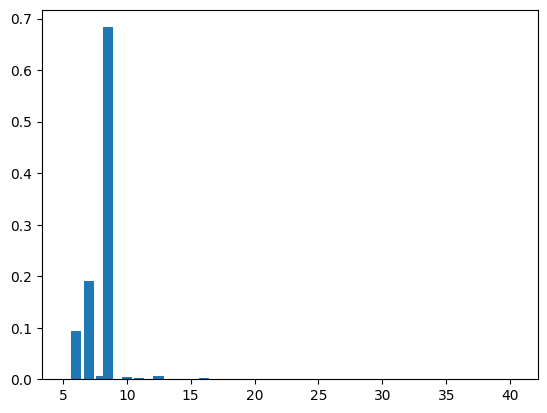

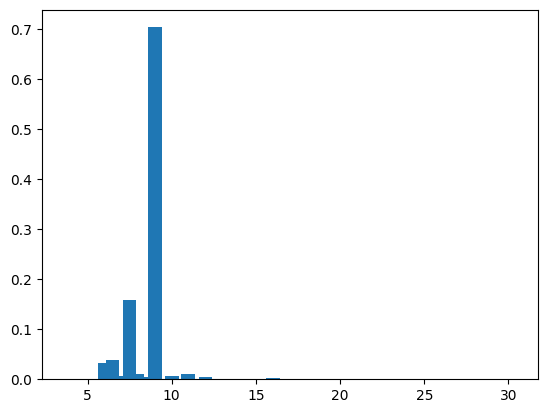

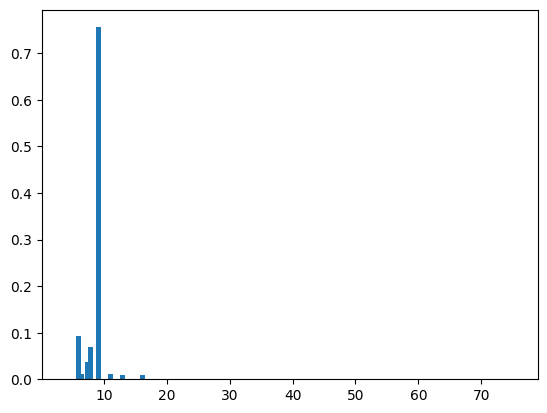

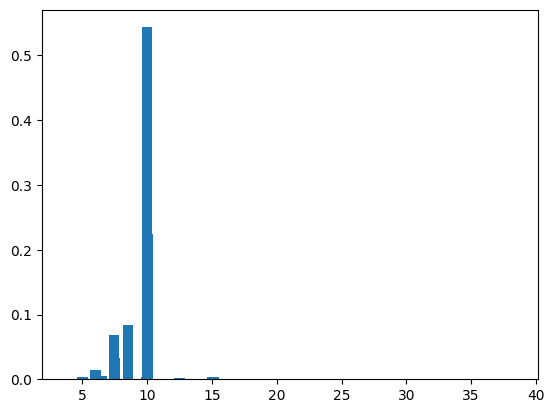

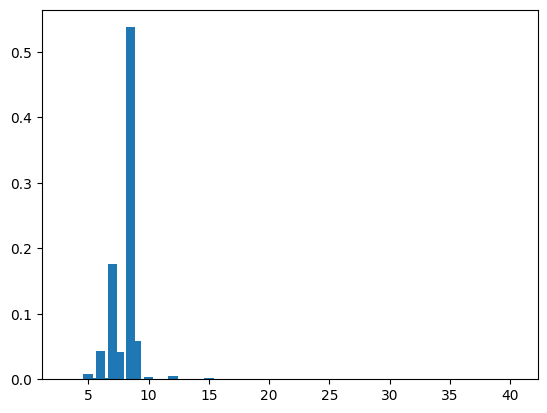

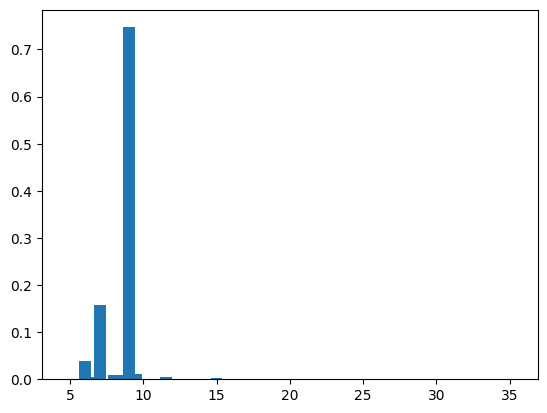

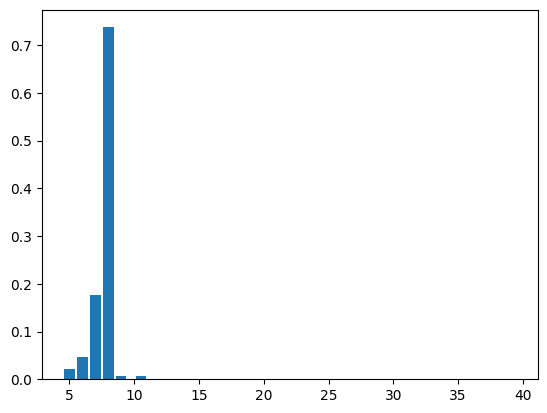

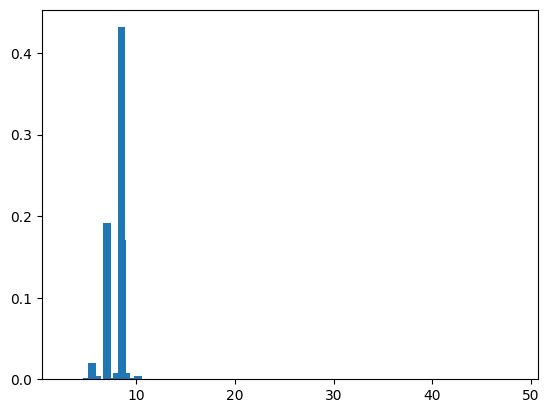

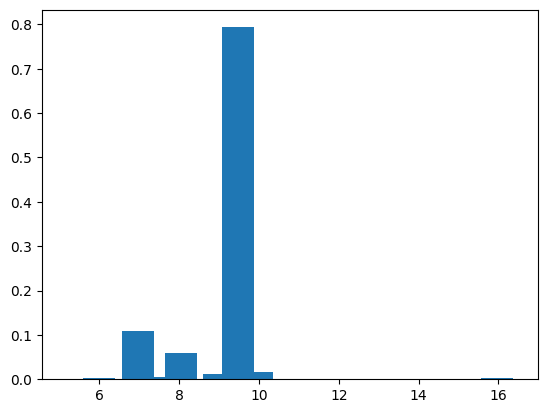

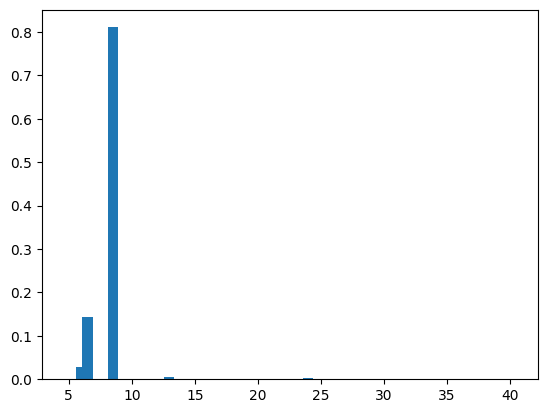

In [ ]:
for r in record_font_sizes: 
    plt.bar(r.index, r["share"])
    plt.show()

In [ ]:
record_font_sizes[2].index

Index([ 9.119999885559082,                6.0,  7.920000076293945,
        7.440000057220459, 11.039999961853027,  6.480000019073486,
       16.079999923706055, 12.960000038146973, 22.079999923706055,
                     12.0, 13.920000076293945,  9.550749778747559,
        9.605055809020996,  9.545395851135254,               18.0,
                      8.0,               70.0,               20.0,
                     16.0,  4.079999923706055,               35.0,
                     75.0, 49.944000244140625],
      dtype='float64', name='font_size')